In [10]:
# Linear Regression on Heart Disease Dataset
# Libraries: scikit-learn, numpy, pandas, matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
# 1. Load dataset
df = pd.read_csv("cleaned_merged_heart_dataset.csv")

In [12]:
# 2. Inspect columns
print("Columns:", df.columns)

Columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [13]:
# 3. Define features (X) and target (y)
# We'll use all clinical features except the target
X = df[['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalachh','exang','oldpeak','slope','ca','thal']]

y = df['target']   # target: presence of heart disease (0/1)

In [14]:
# 4. Handle missing values (if any)
X = X.fillna(X.mean())

In [15]:
# 5. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# 6. Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# 7. Predict on test set
y_pred = model.predict(X_test)

In [18]:
# 8. Evaluate model
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Intercept: 0.5898800797153305
Coefficients: [-0.00097419 -0.15932098  0.1316607  -0.00121189 -0.00048708 -0.01510986
  0.04276566  0.0012013  -0.11754148 -0.03103165  0.16200261 -0.07718572
 -0.0294715 ]
Mean Squared Error: 0.1851790073933762
R² Score: 0.25926323369554416


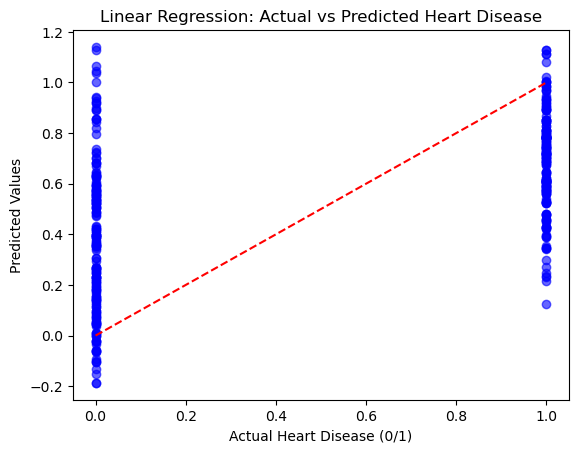

In [19]:
# 9. Visualization: Actual vs Predicted
plt.scatter(y_test, y_pred, color="blue", alpha=0.6)
plt.xlabel("Actual Heart Disease (0/1)")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted Heart Disease")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.show()